Introduction:

This project focuses on analyzing banking transaction data to identify patterns and factors associated with fraudulent transactions. Exploratory Data Analysis (EDA) is used to understand transaction behavior, detect unusual patterns, and identify potential fraud indicators.

Business Problem:

The bank needs to identify potentially fraudulent transactions while minimizing false alarms. The objective is to determine which transaction patterns, such as location changes, failed attempts, transaction type, device type, amount, and transaction time, are associated with higher fraud risk and can help the bank improve fraud monitoring.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

phase 1- understanding the Data

In [ ]:
df=pd.read_csv(r"C:\Users\ASUS\Downloads\banking_fraud_data_10000.csv")
df
  #dataset is loaded

,Transaction_ID,Customer_ID,Age,City,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location_Change,Transaction_Time_Hour,Is_Weekend,Failed_Transactions_Last_24h,Is_Fraud
0,TXN000001,CUST00224,51.0,Mumbai,20165.96,ATM,11695.06,ATM,No,10.0,Yes,0.0,0
1,TXN000002,CUST01935,27.0,Bengaluru,80057.08,Online,67506.61,Mobile,Yes,17.0,No,0.0,0
2,TXN000003,CUST01637,37.0,Bengaluru,11593.67,POS,44740.16,Mobile,Yes,4.0,Yes,1.0,1
3,TXN000004,CUST01098,54.0,Chennai,11208.39,POS,261985.75,Mobile,No,20.0,No,0.0,0
4,TXN000005,CUST01083,54.0,Bengaluru,12673.87,Online,21390.58,Mobile,No,11.0,No,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN009996,CUST01178,45.0,Hyderabad,20955.86,POS,105949.88,Card,Yes,0.0,No,1.0,0
9996,TXN009997,CUST02492,25.0,Mumbai,22601.72,Online,20853.03,Mobile,No,8.0,No,1.0,0
9997,TXN009998,CUST00883,39.0,Hyderabad,17599.32,Online,113282.82,Laptop,Yes,9.0,No,0.0,0
9998,TXN009999,CUST01414,66.0,Visakhapatnam,6188.04,Online,207406.67,Mobile,Yes,12.0,No,2.0,0


In [ ]:
df.head() # first 5sets of dataframe

,Transaction_ID,Customer_ID,Age,City,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location_Change,Transaction_Time_Hour,Is_Weekend,Failed_Transactions_Last_24h,Is_Fraud
0,TXN000001,CUST00224,51.0,Mumbai,20165.96,ATM,11695.06,ATM,No,10.0,Yes,0.0,0
1,TXN000002,CUST01935,27.0,Bengaluru,80057.08,Online,67506.61,Mobile,Yes,17.0,No,0.0,0
2,TXN000003,CUST01637,37.0,Bengaluru,11593.67,POS,44740.16,Mobile,Yes,4.0,Yes,1.0,1
3,TXN000004,CUST01098,54.0,Chennai,11208.39,POS,261985.75,Mobile,No,20.0,No,0.0,0
4,TXN000005,CUST01083,54.0,Bengaluru,12673.87,Online,21390.58,Mobile,No,11.0,No,0.0,0


In [ ]:
df.tail() # last 5sets of dataframe

,Transaction_ID,Customer_ID,Age,City,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location_Change,Transaction_Time_Hour,Is_Weekend,Failed_Transactions_Last_24h,Is_Fraud
9995,TXN009996,CUST01178,45.0,Hyderabad,20955.86,POS,105949.88,Card,Yes,0.0,No,1.0,0
9996,TXN009997,CUST02492,25.0,Mumbai,22601.72,Online,20853.03,Mobile,No,8.0,No,1.0,0
9997,TXN009998,CUST00883,39.0,Hyderabad,17599.32,Online,113282.82,Laptop,Yes,9.0,No,0.0,0
9998,TXN009999,CUST01414,66.0,Visakhapatnam,6188.04,Online,207406.67,Mobile,Yes,12.0,No,2.0,0
9999,TXN010000,CUST01539,62.0,Chennai,22368.53,Online,23857.63,Mobile,No,8.0,No,0.0,0


In [ ]:
df.shape  # rows and columns

(10000, 13)

In [ ]:
df.columns   # column names

Index(['Transaction_ID', 'Customer_ID', 'Age', 'City', 'Transaction_Amount',
       'Transaction_Type', 'Account_Balance', 'Device_Type', 'Location_Change',
       'Transaction_Time_Hour', 'Is_Weekend', 'Failed_Transactions_Last_24h',
       'Is_Fraud'],
      dtype='str')

In [ ]:
df.dtypes  # checking the data types

Transaction_ID                      str
Customer_ID                         str
Age                             float64
City                                str
Transaction_Amount              float64
Transaction_Type                    str
Account_Balance                 float64
Device_Type                         str
Location_Change                     str
Transaction_Time_Hour           float64
Is_Weekend                          str
Failed_Transactions_Last_24h    float64
Is_Fraud                          int64
dtype: object

In [ ]:
df.info() # entire dataset information

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                10000 non-null  str    
 1   Customer_ID                   10000 non-null  str    
 2   Age                           9975 non-null   float64
 3   City                          9980 non-null   str    
 4   Transaction_Amount            9982 non-null   float64
 5   Transaction_Type              9985 non-null   str    
 6   Account_Balance               9978 non-null   float64
 7   Device_Type                   9985 non-null   str    
 8   Location_Change               9988 non-null   str    
 9   Transaction_Time_Hour         9985 non-null   float64
 10  Is_Weekend                    9990 non-null   str    
 11  Failed_Transactions_Last_24h  9985 non-null   float64
 12  Is_Fraud                      10000 non-null  int64  
dtypes: float64(5)

In [ ]:
df.describe() # statistical summary of the dataset

,Age,Transaction_Amount,Account_Balance,Transaction_Time_Hour,Failed_Transactions_Last_24h,Is_Fraud
count,9975.000000,9.982000e+03,9978.000000,9985.000000,9985.000000,10000.000000
mean,45.644311,4.260766e+04,78758.417265,12.959740,0.847872,0.131400
std,14.501716,1.366359e+05,76203.640283,6.102521,0.906370,0.337854
min,12.000000,-4.862600e+03,-19234.130000,-5.000000,0.000000,0.000000
25%,33.000000,7.982452e+03,30835.890000,8.000000,0.000000,0.000000
50%,46.000000,1.428474e+04,55028.580000,13.000000,1.000000,0.000000
75%,58.000000,2.555225e+04,98364.657500,18.000000,1.000000,0.000000
max,108.000000,1.789817e+06,500000.000000,30.000000,5.000000,1.000000


In [ ]:
df.select_dtypes(include='number').columns  #numerical columns

Index(['Age', 'Transaction_Amount', 'Account_Balance', 'Transaction_Time_Hour',
       'Failed_Transactions_Last_24h', 'Is_Fraud'],
      dtype='str')

In [ ]:
df.select_dtypes(include='str').columns  #categorical columns #flag

Index(['Transaction_ID', 'Customer_ID', 'City', 'Transaction_Type',
       'Device_Type', 'Location_Change', 'Is_Weekend'],
      dtype='str')

In [ ]:
df['Customer_ID'].nunique() #unique customers total

2451

In [ ]:
df['Transaction_ID'].nunique() #unique total transactions

10000

In [ ]:
df['Transaction_Type'].unique()       # unique transaction types

<StringArray>
['ATM', 'Online', 'POS', nan]
Length: 4, dtype: str

In [ ]:
df['Device_Type'].nunique()

4

In [ ]:
df['City'].nunique()

8

In [ ]:
df.shape[0]

10000

questions
1. How many transactions are present?

   10000 transactions

2. How many customers are present?

   2451 customers

3. What types of transactions are available?

  ATM, Online, POS, nan are available
   
4. Which columns are numerical?

  ['Age', 'Transaction_Amount', 'Account_Balance', 'Transaction_Time_Hour',
       'Failed_Transactions_Last_24h', 'Is_Fraud'] are numerical
 
5. Which columns are categorical?

  ['Transaction_ID', 'Customer_ID', 'City', 'Transaction_Type',
       'Device_Type', 'Location_Change', 'Is_Weekend'] are categorical


Phase 2 – Data Quality Investigation

In [ ]:
df.columns[df.isnull().sum()>0]  #identifying if any columns has null values

Index(['Age', 'City', 'Transaction_Amount', 'Transaction_Type',
       'Account_Balance', 'Device_Type', 'Location_Change',
       'Transaction_Time_Hour', 'Is_Weekend', 'Failed_Transactions_Last_24h'],
      dtype='str')

In [ ]:
df.isnull().sum().sum() # sum of missing values in entire table

np.int64(167)

In [ ]:
df.isnull().sum()/len(df)*100  #perecantage of each column missing

Transaction_ID                  0.00
Customer_ID                     0.00
Age                             0.25
City                            0.20
Transaction_Amount              0.18
Transaction_Type                0.15
Account_Balance                 0.22
Device_Type                     0.15
Location_Change                 0.12
Transaction_Time_Hour           0.15
Is_Weekend                      0.10
Failed_Transactions_Last_24h    0.15
Is_Fraud                        0.00
dtype: float64

In [ ]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Age', 'City', 'Transaction_Amount',
       'Transaction_Type', 'Account_Balance', 'Device_Type', 'Location_Change',
       'Transaction_Time_Hour', 'Is_Weekend', 'Failed_Transactions_Last_24h',
       'Is_Fraud'],
      dtype='str')

In [ ]:
df=pd.read_csv(r"C:\Users\ASUS\Downloads\banking_fraud_data_10000.csv")
df

,Transaction_ID,Customer_ID,Age,City,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location_Change,Transaction_Time_Hour,Is_Weekend,Failed_Transactions_Last_24h,Is_Fraud
0,TXN000001,CUST00224,51.0,Mumbai,20165.96,ATM,11695.06,ATM,No,10.0,Yes,0.0,0
1,TXN000002,CUST01935,27.0,Bengaluru,80057.08,Online,67506.61,Mobile,Yes,17.0,No,0.0,0
2,TXN000003,CUST01637,37.0,Bengaluru,11593.67,POS,44740.16,Mobile,Yes,4.0,Yes,1.0,1
3,TXN000004,CUST01098,54.0,Chennai,11208.39,POS,261985.75,Mobile,No,20.0,No,0.0,0
4,TXN000005,CUST01083,54.0,Bengaluru,12673.87,Online,21390.58,Mobile,No,11.0,No,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN009996,CUST01178,45.0,Hyderabad,20955.86,POS,105949.88,Card,Yes,0.0,No,1.0,0
9996,TXN009997,CUST02492,25.0,Mumbai,22601.72,Online,20853.03,Mobile,No,8.0,No,1.0,0
9997,TXN009998,CUST00883,39.0,Hyderabad,17599.32,Online,113282.82,Laptop,Yes,9.0,No,0.0,0
9998,TXN009999,CUST01414,66.0,Visakhapatnam,6188.04,Online,207406.67,Mobile,Yes,12.0,No,2.0,0


In [ ]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Age', 'City', 'Transaction_Amount',
       'Transaction_Type', 'Account_Balance', 'Device_Type', 'Location_Change',
       'Transaction_Time_Hour', 'Is_Weekend', 'Failed_Transactions_Last_24h',
       'Is_Fraud'],
      dtype='str')

In [ ]:
df.isnull().sum() #null values for each row

Transaction_ID                   0
Customer_ID                      0
Age                             25
City                            20
Transaction_Amount              18
Transaction_Type                15
Account_Balance                 22
Device_Type                     15
Location_Change                 12
Transaction_Time_Hour           15
Is_Weekend                      10
Failed_Transactions_Last_24h    15
Is_Fraud                         0
dtype: int64

In [ ]:
df['Age']=df['Age'].fillna(df['Age'].median()) #numerical null values replaced with median
df['Transaction_Amount']=df['Transaction_Amount'].fillna(df['Transaction_Amount'].median())
df['Account_Balance']=df['Account_Balance'].fillna(df['Account_Balance'].median())
df['Transaction_Time_Hour']=df['Transaction_Time_Hour'].fillna(df['Transaction_Time_Hour'].median())
df['Failed_Transactions_Last_24h']=df['Failed_Transactions_Last_24h'].fillna(df['Failed_Transactions_Last_24h'].median())
df['Is_Fraud']=df['Is_Fraud'].fillna(df['Is_Fraud'].median())

In [ ]:
df['City']=df['City'].fillna(df['City'].mode()[0]) #categorical null values  replaced with mode
df['Transaction_Type']=df['Transaction_Type'].fillna(df['Transaction_Type'].mode()[0])
df['Device_Type']=df['Device_Type'].fillna(df['Device_Type'].mode()[0])
df['Location_Change']=df['Location_Change'].fillna(df['Location_Change'].mode()[0])
df['Is_Weekend']=df['Is_Weekend'].fillna(df['Is_Weekend'].mode()[0])


In [ ]:
df.isnull().sum()  ##this is the way to remove null values

Transaction_ID                  0
Customer_ID                     0
Age                             0
City                            0
Transaction_Amount              0
Transaction_Type                0
Account_Balance                 0
Device_Type                     0
Location_Change                 0
Transaction_Time_Hour           0
Is_Weekend                      0
Failed_Transactions_Last_24h    0
Is_Fraud                        0
dtype: int64

Which columns contain missing values?

Age, City, Transaction_Amount, Transaction_Type, Account_Balance, Device_Type, Location_Change, Transaction_Time_Hour, Is_Weekend, Failed_Transactions_Last_24h

How many missing values are present?

There are 174 missing values in total.

• What percentage of each column is missing?

Transaction_ID                  0
Customer_ID                     0
Age                             0.25%
City                            0.20%
Transaction_Amount              0.18%
Transaction_Type                0.15%
Account_Balance                 0.22%
Device_Type                     0.15%
Location_Change                 0.12%
Transaction_Time_Hour           0.15%
Is_Weekend                      0.10%
Failed_Transactions_Last_24h    0.15%
Is_Fraud                        0.

Numerical columns: I selected median because it is less affected by extreme values or outliers.

Categorical columns: I selected mode because it replaces missing values with the most frequent category.

In [ ]:
df=pd.read_csv(r"C:\Users\ASUS\Downloads\banking_fraud_data_10000.csv")
df

,Transaction_ID,Customer_ID,Age,City,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location_Change,Transaction_Time_Hour,Is_Weekend,Failed_Transactions_Last_24h,Is_Fraud
0,TXN000001,CUST00224,51.0,Mumbai,20165.96,ATM,11695.06,ATM,No,10.0,Yes,0.0,0
1,TXN000002,CUST01935,27.0,Bengaluru,80057.08,Online,67506.61,Mobile,Yes,17.0,No,0.0,0
2,TXN000003,CUST01637,37.0,Bengaluru,11593.67,POS,44740.16,Mobile,Yes,4.0,Yes,1.0,1
3,TXN000004,CUST01098,54.0,Chennai,11208.39,POS,261985.75,Mobile,No,20.0,No,0.0,0
4,TXN000005,CUST01083,54.0,Bengaluru,12673.87,Online,21390.58,Mobile,No,11.0,No,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN009996,CUST01178,45.0,Hyderabad,20955.86,POS,105949.88,Card,Yes,0.0,No,1.0,0
9996,TXN009997,CUST02492,25.0,Mumbai,22601.72,Online,20853.03,Mobile,No,8.0,No,1.0,0
9997,TXN009998,CUST00883,39.0,Hyderabad,17599.32,Online,113282.82,Laptop,Yes,9.0,No,0.0,0
9998,TXN009999,CUST01414,66.0,Visakhapatnam,6188.04,Online,207406.67,Mobile,Yes,12.0,No,2.0,0


Phase 3 – Identify Invalid Data 

In [ ]:
(df['Transaction_Amount']<0).sum()  # total negative transaction amounts

np.int64(12)

In [ ]:
(df['Transaction_Amount']==0).sum() # total zero transaction amounts

np.int64(12)

In [ ]:
#to caluclate extreme total high transaction values using IQR
Q1=df['Transaction_Amount'].quantile(0.25)
Q3=df['Transaction_Amount'].quantile(0.75)
IQR=Q3-Q1
upper_limit=Q3+1.5*IQR
df[df['Transaction_Amount']>upper_limit].shape[0]

1238

In [ ]:
(df['Account_Balance']<0).sum() # count of negative account balance

np.int64(10)

In [ ]:
df[df['Transaction_Amount']>df['Account_Balance']].shape[0] #count of transaction amounts that are greater than account balanace

1736

In [ ]:
df[(df['Age']>100) | (df['Age']<18)].shape[0] #unrealistic ages count

16

In [ ]:
df[(df['Transaction_Time_Hour']<0) | (df['Transaction_Time_Hour']>23)].shape[0] #invalid tranasaction time count

16

1.Which records contain invalid values?

All tansaction amount,account balanace,age and transaction time contains invalid values

2.Should these records be removed or corrected?

Remove: Delete negative/zero transaction amounts and unrealistic ages if they represent impossible entry errors that cannot be recovered.

Correct: Adjust negative account balances if overdrafts are allowed, or flag them. Do not delete high transaction values or transactions exceeding balance—keep them for fraud detection or apply transformations  as they may be valid high-value activity.

3. What assumptions did you make?

Valid Ranges: Transactions must be strictly positive  and adult customer ages strictly fall between 18 and 100.

Overdraft Policy: Negative balances are system anomalies rather than intentional credit limits.Outliers

Errors: High transaction amounts flagged by IQR are treated as potential heavy-use anomalies rather than corrupted data.



Phase 4 – Outlier Detection 

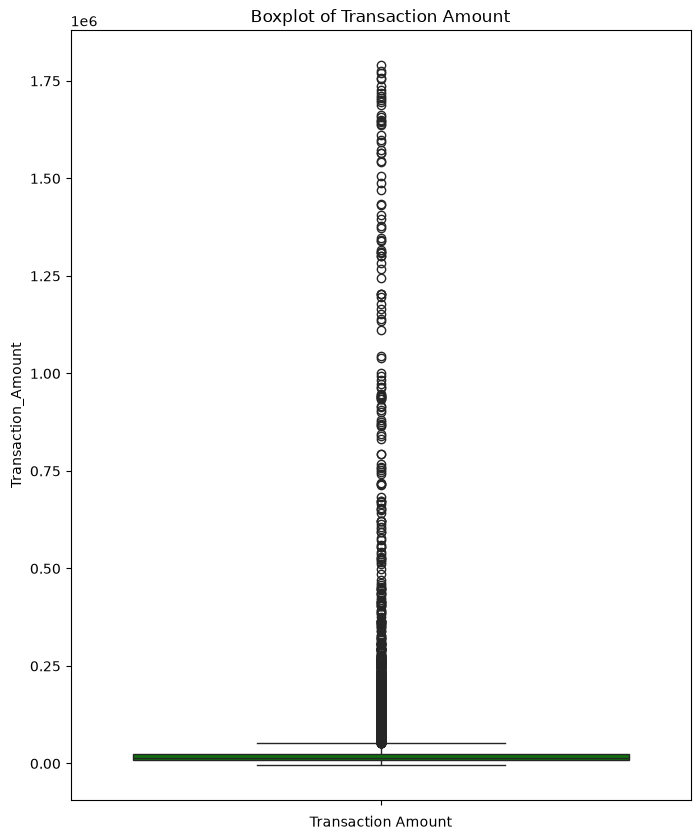

In [ ]:
#method 1 boxplot
plt.figure(figsize=(8,10))
sns.boxplot(y=df['Transaction_Amount'], color='green')

plt.title('Boxplot of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.show()


In [ ]:
#IQR method
Q1=df['Transaction_Amount'].quantile(0.25)
Q3=df['Transaction_Amount'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers = df[(df['Transaction_Amount'] < lower_bound) | (df['Transaction_Amount'] > upper_bound)].shape[0]
print(outliers)


1238


1. How many outliers are present?

   1238 based on IQR method 

2. Which transactions are outliers?

  Transactions whose values fall below lowerbound or above upperbound are outliers.

3. Are all outliers fraudulent?

  No. An outlier does not necessarily mean the transaction is fraudulent

4. Should an outlier automatically be considered fraud?

  No. Outliers are unusual transactions, but they require further analysis before being classified as fraud.

 Is an outlier necessarily an error?
 
 No. An outlier is not necessarily an error.
 An outlier simply means the value is unusually high or low compared with most transactions. It could be a legitimate transaction.



Phase 5 – NumPy Analysis 

In [ ]:
df['Transaction_Amount'].mean() 

np.float64(42607.65686936486)

In [ ]:
df['Transaction_Amount'].median()

np.float64(14284.74)

In [ ]:
df['Transaction_Amount'].std()

np.float64(136635.87222400287)

In [ ]:
df['Transaction_Amount'].min()

np.float64(-4862.6)

In [ ]:
df['Transaction_Amount'].max()

np.float64(1789817.42)

In [ ]:
np.percentile(df['Transaction_Amount'].dropna(),[25,50,75,90,95,99])

array([  7982.4525    ,  14284.74      ,  25552.2525    ,  74836.679     ,
       152231.1715    , 674776.77700001])

In [ ]:
#compare fraudulent transactions with non-fraudulent transaction
fraud=df[df['Is_Fraud']==1]['Transaction_Amount'] #fraud transactions
non_fraud=df[df['Is_Fraud']==0]['Transaction_Amount']# non fraud transactions


In [ ]:
print(fraud.mean(),non_fraud.mean()) #comparision between fraud and non fraud mean         


73737.89714939025 37896.8292745098


In [ ]:
print(fraud.median(),non_fraud.median()) #comparision between fraud and non fraud median

19210.3 13766.485


In [ ]:
print(fraud.std(),non_fraud.std()) #comparision between fraud and non fraud median

192188.06791604686 125459.87266498305


Is the average transaction amount higher for fraudulent transactions? 

Average fradulent transactions is higher than the non fradudelent transactions beacuse mean and median of  fradulent transactions are higher than the non fradudelent transactions.

                                                 
 fradulent transactions 

  mean:73737.89714939025 

  median:19210.3

 non fradudelent transactions
 
  mean:37896.8292745098        
  
  median:13766.485


Phase 6 – Fraud Distribution Analysis 

In [ ]:
len(fraud) #number of fraud transactions

1314

In [ ]:
len(non_fraud) #Number of legitimate transactions 

8686

In [ ]:
Fraud_percentage=(len(fraud)/len(df['Transaction_Amount'])*100)
print(Fraud_percentage)   ##fraud percentage in dataset

13.139999999999999


Text(0.5, 1.0, 'Fraud vs Non-Fraud')

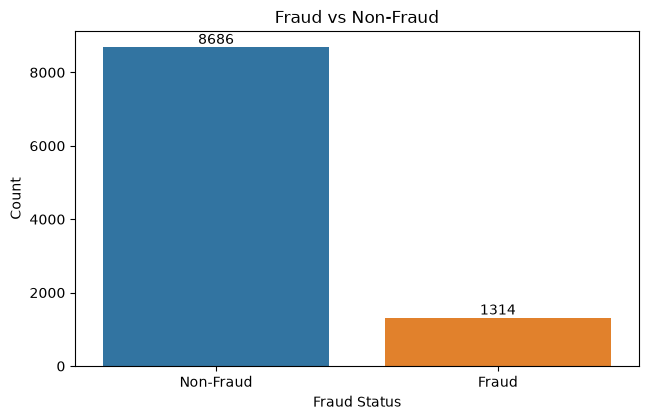

In [ ]:
#visualization for Fraud vs Non-Fraud 
plt.figure(figsize=(16, 20))


# 1. Fraud vs Non-Fraud
plt.subplot(4, 2, 1)

ax = sns.countplot(
    x='Is_Fraud',
    hue='Is_Fraud',
    data=df,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.xlabel('Fraud Status')
plt.ylabel('Count')
plt.title('Fraud vs Non-Fraud')

Is the dataset balanced or imbalanced? 

The dataset is imbalanced.
Out of 10,000 total records, 8,686 (86.86%) are non-fraudulent and 1,314 (13.14%) are fraudulent this makes dataset heavily imbalanced

Why could class imbalance become a problem in a real fraud detection system? 

A model can score a  high 86.86% accuracy simply by guessing non-fraud every time while catching zero actual fraud this will lead to wrong prediction and would unable to caught the financial losses and misleading values.

In [ ]:
onlinefraud=len(df[(df['Transaction_Type']=='Online')&(df['Is_Fraud']==1)])
print(onlinefraud)  ##analyzing onlinefraud transactions

826


In [ ]:
ATM_fraud=len(df[(df['Transaction_Type']=='ATM')&(df['Is_Fraud']==1)])
print(ATM_fraud)  ##analyzing ATMfraud transactions

239


In [ ]:
POS_fraud=len(df[(df['Transaction_Type']=='POS')&(df['Is_Fraud']==1)])
print(POS_fraud)  ##analyzing POSfraud transactions

247


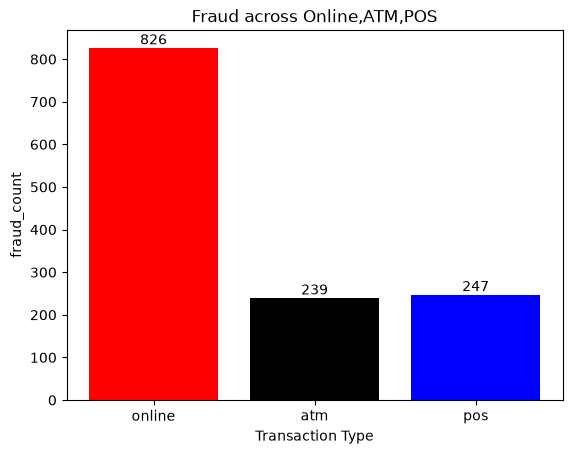

In [ ]:
#appropriate visualization for Analyze fraud across Online,ATM ,POS 
fraud_count=len(fraud)
types=['online','atm','pos']
values=[onlinefraud,ATM_fraud,POS_fraud]
plt.figure()
bars = plt.bar(types, values, color=['red', 'black', 'blue'])
plt.xlabel('Transaction Type')
plt.ylabel('fraud_count')
plt.title('Fraud across Online,ATM,POS')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 1, str(h), ha='center', va='bottom')
plt.show()

In [ ]:
online=len(df[(df['Transaction_Type']=='Online')])   #checking fraud rates
atm=len(df[(df['Transaction_Type']=='ATM')])
pos=len(df[(df['Transaction_Type']=='POS')])
print((onlinefraud/online)*100,(ATM_fraud/atm)*100,(POS_fraud/pos)*100)


16.013958898797984 10.279569892473118 9.872102318145485


1. Which transaction type has the highest number of fraud cases? 

    Online transaction type has the highest number of fraud cases with 826 transactions.

2. Which transaction type has the highest fraud rate? 

    Online payments has the highest fraud rate with 16.013958898797984

3. Is online banking more risky than ATM/POS? 

   Yes Online payments do not require a physical card or PIN, making them the easiest entry point for stolen card details, credential stuffing, and phishing scams.


Phase 8 – Device Analysis 

In [ ]:
Mobile_fraud=len(df[(df['Device_Type']=='Mobile')&(df['Is_Fraud']==1)])
Laptop_fraud=len(df[(df['Device_Type']=='Laptop')&(df['Is_Fraud']==1)])
ATM_Fraud=len(df[(df['Device_Type']=='ATM')&(df['Is_Fraud']==1)])
Card_Fraud=len(df[(df['Device_Type']=='Card')&(df['Is_Fraud']==1)])







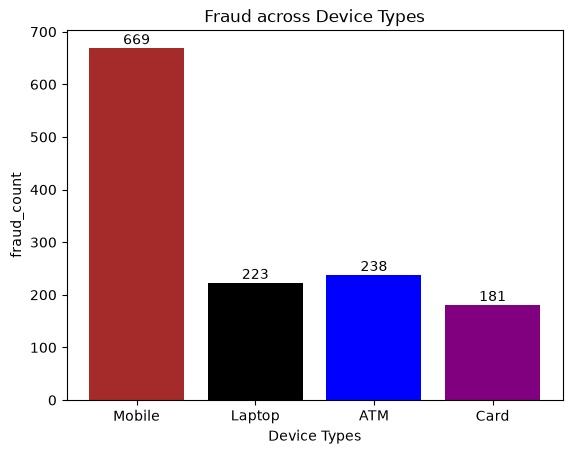

In [ ]:
types=['Mobile','Laptop','ATM','Card']
values=[Mobile_fraud,Laptop_fraud,ATM_Fraud,Card_Fraud]
plt.figure()
bars = plt.bar(types, values, color=['brown', 'black', 'blue','purple'])
plt.xlabel('Device Types')
plt.ylabel('fraud_count')
plt.title('Fraud across Device Types')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 1, str(h), ha='center', va='bottom')
plt.show()

In [ ]:
mobile=len(df[(df['Device_Type']=='Mobile')])   #checking fraud rates for devices
laptop=len(df[(df['Device_Type']=='Laptop')])
atm1=len(df[(df['Device_Type']=='ATM')])
card=len(df[(df['Device_Type']=='Card')])

print((Mobile_fraud/mobile)*100,(Laptop_fraud/laptop)*100,(ATM_Fraud/atm1)*100,(Card_Fraud/card)*100)

16.91102123356926 13.109935332157555 10.227761065749892 9.045477261369316


1. Which device is associated with the highest fraud? 

   Mobile with 669 fraud transactions

2. Does the device type appear to influence fraud? 

   Yes, device type strongly influences fraud.
   Mobile devices are by far the primary vector for fraudulent activity in this dataset, accounting for 669 cases—which represents 50.9% (over half) of all fraud transactions.

3. What percentage of transactions from each device are fraudulent? 

   Mobile: 16.91%  — Highest risk

   ATM: 13.11% 

   Laptop: 10.23% 
   
   Card : 9.05% — Lowest risk

Phase 9 – Location Change Analysis 

In [ ]:
locationchange=len(df[(df['Location_Change']=='Yes')&(df['Is_Fraud']==1)])

In [ ]:
locationnotchange=len(df[(df['Location_Change']=='No')&(df['Is_Fraud']==1)])

In [ ]:

print(locationchange,locationnotchange)


586 727


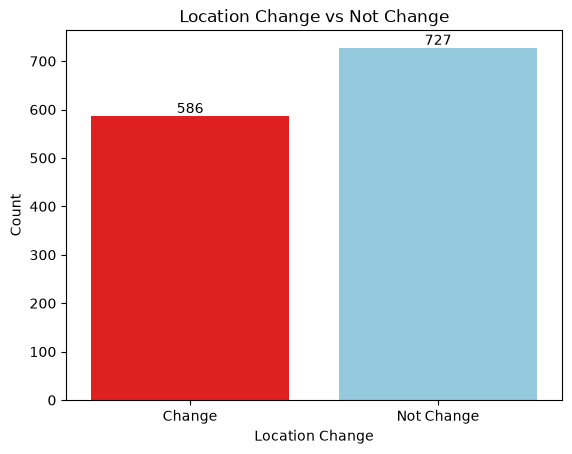

In [ ]:
data = pd.DataFrame({
    'Location': ['Change', 'Not Change'],
    'Count': [locationchange, locationnotchange]
})

ax = sns.barplot(
    x='Location',
    y='Count',
    hue='Location',
    data=data,
    palette=['red', 'skyblue'],
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Location Change')
plt.ylabel('Count')
plt.title('Location Change vs Not Change')
plt.show()

Are transactions involving a location change more likely to be fraudulent? 

NO locations that are not changed has more fraud so it doesnt depend on location

In [ ]:
df.head()

,Transaction_ID,Customer_ID,Age,City,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location_Change,Transaction_Time_Hour,Is_Weekend,Failed_Transactions_Last_24h,Is_Fraud
0,TXN000001,CUST00224,51.0,Mumbai,20165.96,ATM,11695.06,ATM,No,10.0,Yes,0.0,0
1,TXN000002,CUST01935,27.0,Bengaluru,80057.08,Online,67506.61,Mobile,Yes,17.0,No,0.0,0
2,TXN000003,CUST01637,37.0,Bengaluru,11593.67,POS,44740.16,Mobile,Yes,4.0,Yes,1.0,1
3,TXN000004,CUST01098,54.0,Chennai,11208.39,POS,261985.75,Mobile,No,20.0,No,0.0,0
4,TXN000005,CUST01083,54.0,Bengaluru,12673.87,Online,21390.58,Mobile,No,11.0,No,0.0,0


In [ ]:
def time_category(hour):
    if 5 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 16:
        return 'Afternoon'
    elif 17 <= hour <= 20:
        return 'Evening'
    elif 21 <= hour <= 23:
        return 'Night'
    else:
        return 'Late Night'

df['Time_Category'] = df['Transaction_Time_Hour'].apply(time_category)

In [ ]:
fraud_by_time = pd.crosstab(df['Time_Category'], df['Is_Fraud'])

print(fraud_by_time)

Is_Fraud          0    1
Time_Category           
Afternoon      2003  278
Evening        1957  254
Late Night      698  204
Morning        2956  439
Night          1072  139


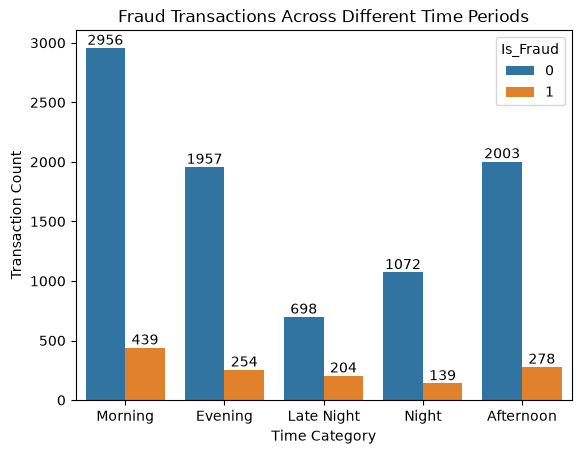

In [ ]:
ax = sns.countplot(
    x='Time_Category',
    hue='Is_Fraud',
    data=df
)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Time Category')
plt.ylabel('Transaction Count')
plt.title('Fraud Transactions Across Different Time Periods')
plt.show()

In [ ]:
fraud_percentage = df.groupby('Time_Category')['Is_Fraud'].mean() * 100

print(fraud_percentage)

Time_Category
Afternoon     12.187637
Evening       11.488014
Late Night    22.616408
Morning       12.930781
Night         11.478117
Name: Is_Fraud, dtype: float64


1.During which time period does fraud occur most frequently?

Morning — 439 fraud transactions, the highest among all periods.

2.Are late-night transactions more suspicious?

Yes. Late Night has 204 fraud transactions out of 902 total, giving a fraud rate of about 22.6%, which is the highest.

3.Is transaction time a useful fraud indicator?

Yes. Fraud rates differ noticeably by time period, with Late Night showing the highest risk (22.6%) and Night the lowest (11.5%).

Phase 11 – Failed Transactions Analysis 

In [ ]:
df.head()

,Transaction_ID,Customer_ID,Age,City,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location_Change,Transaction_Time_Hour,Is_Weekend,Failed_Transactions_Last_24h,Is_Fraud,Time_Category
0,TXN000001,CUST00224,51.0,Mumbai,20165.96,ATM,11695.06,ATM,No,10.0,Yes,0.0,0,Morning
1,TXN000002,CUST01935,27.0,Bengaluru,80057.08,Online,67506.61,Mobile,Yes,17.0,No,0.0,0,Evening
2,TXN000003,CUST01637,37.0,Bengaluru,11593.67,POS,44740.16,Mobile,Yes,4.0,Yes,1.0,1,Late Night
3,TXN000004,CUST01098,54.0,Chennai,11208.39,POS,261985.75,Mobile,No,20.0,No,0.0,0,Evening
4,TXN000005,CUST01083,54.0,Bengaluru,12673.87,Online,21390.58,Mobile,No,11.0,No,0.0,0,Morning


In [ ]:
pd.crosstab(df['Failed_Transactions_Last_24h'], df['Is_Fraud'])

Is_Fraud,0,1
Failed_Transactions_Last_24h,,
0.0,3693,522
1.0,3230,469
2.0,1383,179
3.0,295,118
4.0,57,19
5.0,14,6


In [ ]:
fraud_rate = df.groupby('Failed_Transactions_Last_24h')['Is_Fraud'].mean() * 100
print(fraud_rate)    #fraud rate across failed transaction in last 24h

Failed_Transactions_Last_24h
0.0    12.384342
1.0    12.679102
2.0    11.459667
3.0    28.571429
4.0    25.000000
5.0    30.000000
Name: Is_Fraud, dtype: float64


In [ ]:
fraud_avg = df[df['Is_Fraud'] == 1]['Failed_Transactions_Last_24h'].mean()
print(fraud_avg)

0.9801980198019802


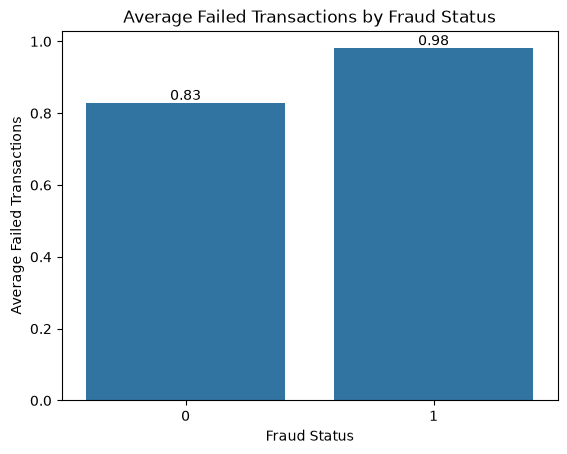

In [ ]:
plt.figure() # 0 means not fraud 1 means fraud comparison betwwen not fraud and fraud across failed transactions visually
avg_failed = df.groupby('Is_Fraud')['Failed_Transactions_Last_24h'].mean()

sns.barplot(
    x=avg_failed.index,
    y=avg_failed.values
)

plt.xlabel('Fraud Status')
plt.ylabel('Average Failed Transactions')
plt.title('Average Failed Transactions by Fraud Status')

for i, value in enumerate(avg_failed.values):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')

plt.show()

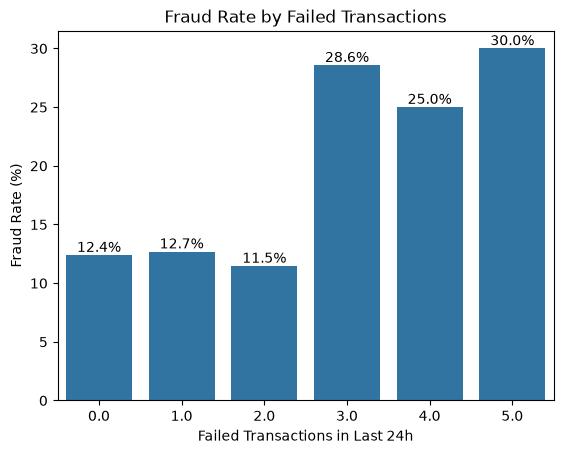

In [ ]:
sns.barplot(                 #visualizing fraud rate across failed transaction in last 24h
    x=fraud_rate.index,
    y=fraud_rate.values
)

plt.xlabel('Failed Transactions in Last 24h')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Failed Transactions')

for i, value in enumerate(fraud_rate.values):
    plt.text(i, value, f'{value:.1f}%', ha='center', va='bottom')

plt.show()

1. Do fraudulent transactions have more failed attempts? 

   Yes. Fraud rate increases notably when failed attempts reach 3 or more.

2. What is the average number of failed transactions for fraud cases? 

    0.9801980198019802
    
3. Does a higher number of failed transactions indicate increased risk? 

   Yes. Higher failed attempts, especially 3+, are associated with higher fraud risk.

Phase 12 – Correlation Analysis

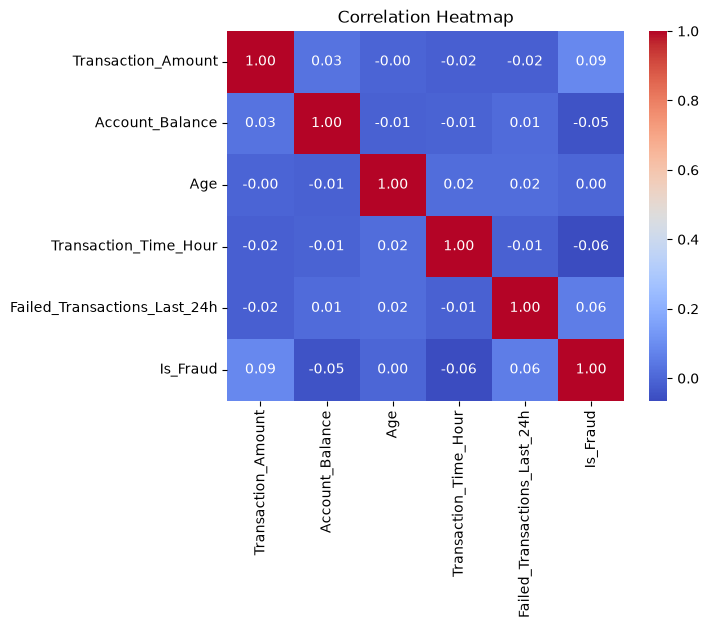

In [ ]:
corr=df[['Transaction_Amount','Account_Balance','Age','Transaction_Time_Hour',
'Failed_Transactions_Last_24h',
           'Is_Fraud']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

1. Which variables have the strongest relationship with fraud?

   Strongest relationship with fraud: Transaction Amount (0.09) has the strongest positive correlation, followed by Failed Transactions (0.06).

2. Which variables appear unrelated?

    Most variables have correlations close to 0, especially Age, Account Balance, and Transaction Time.

3. Are there highly correlated independent variables?

   No. None of the independent variables have a high correlation (close to ±1).


Phase 13 – Visualization Dashboard

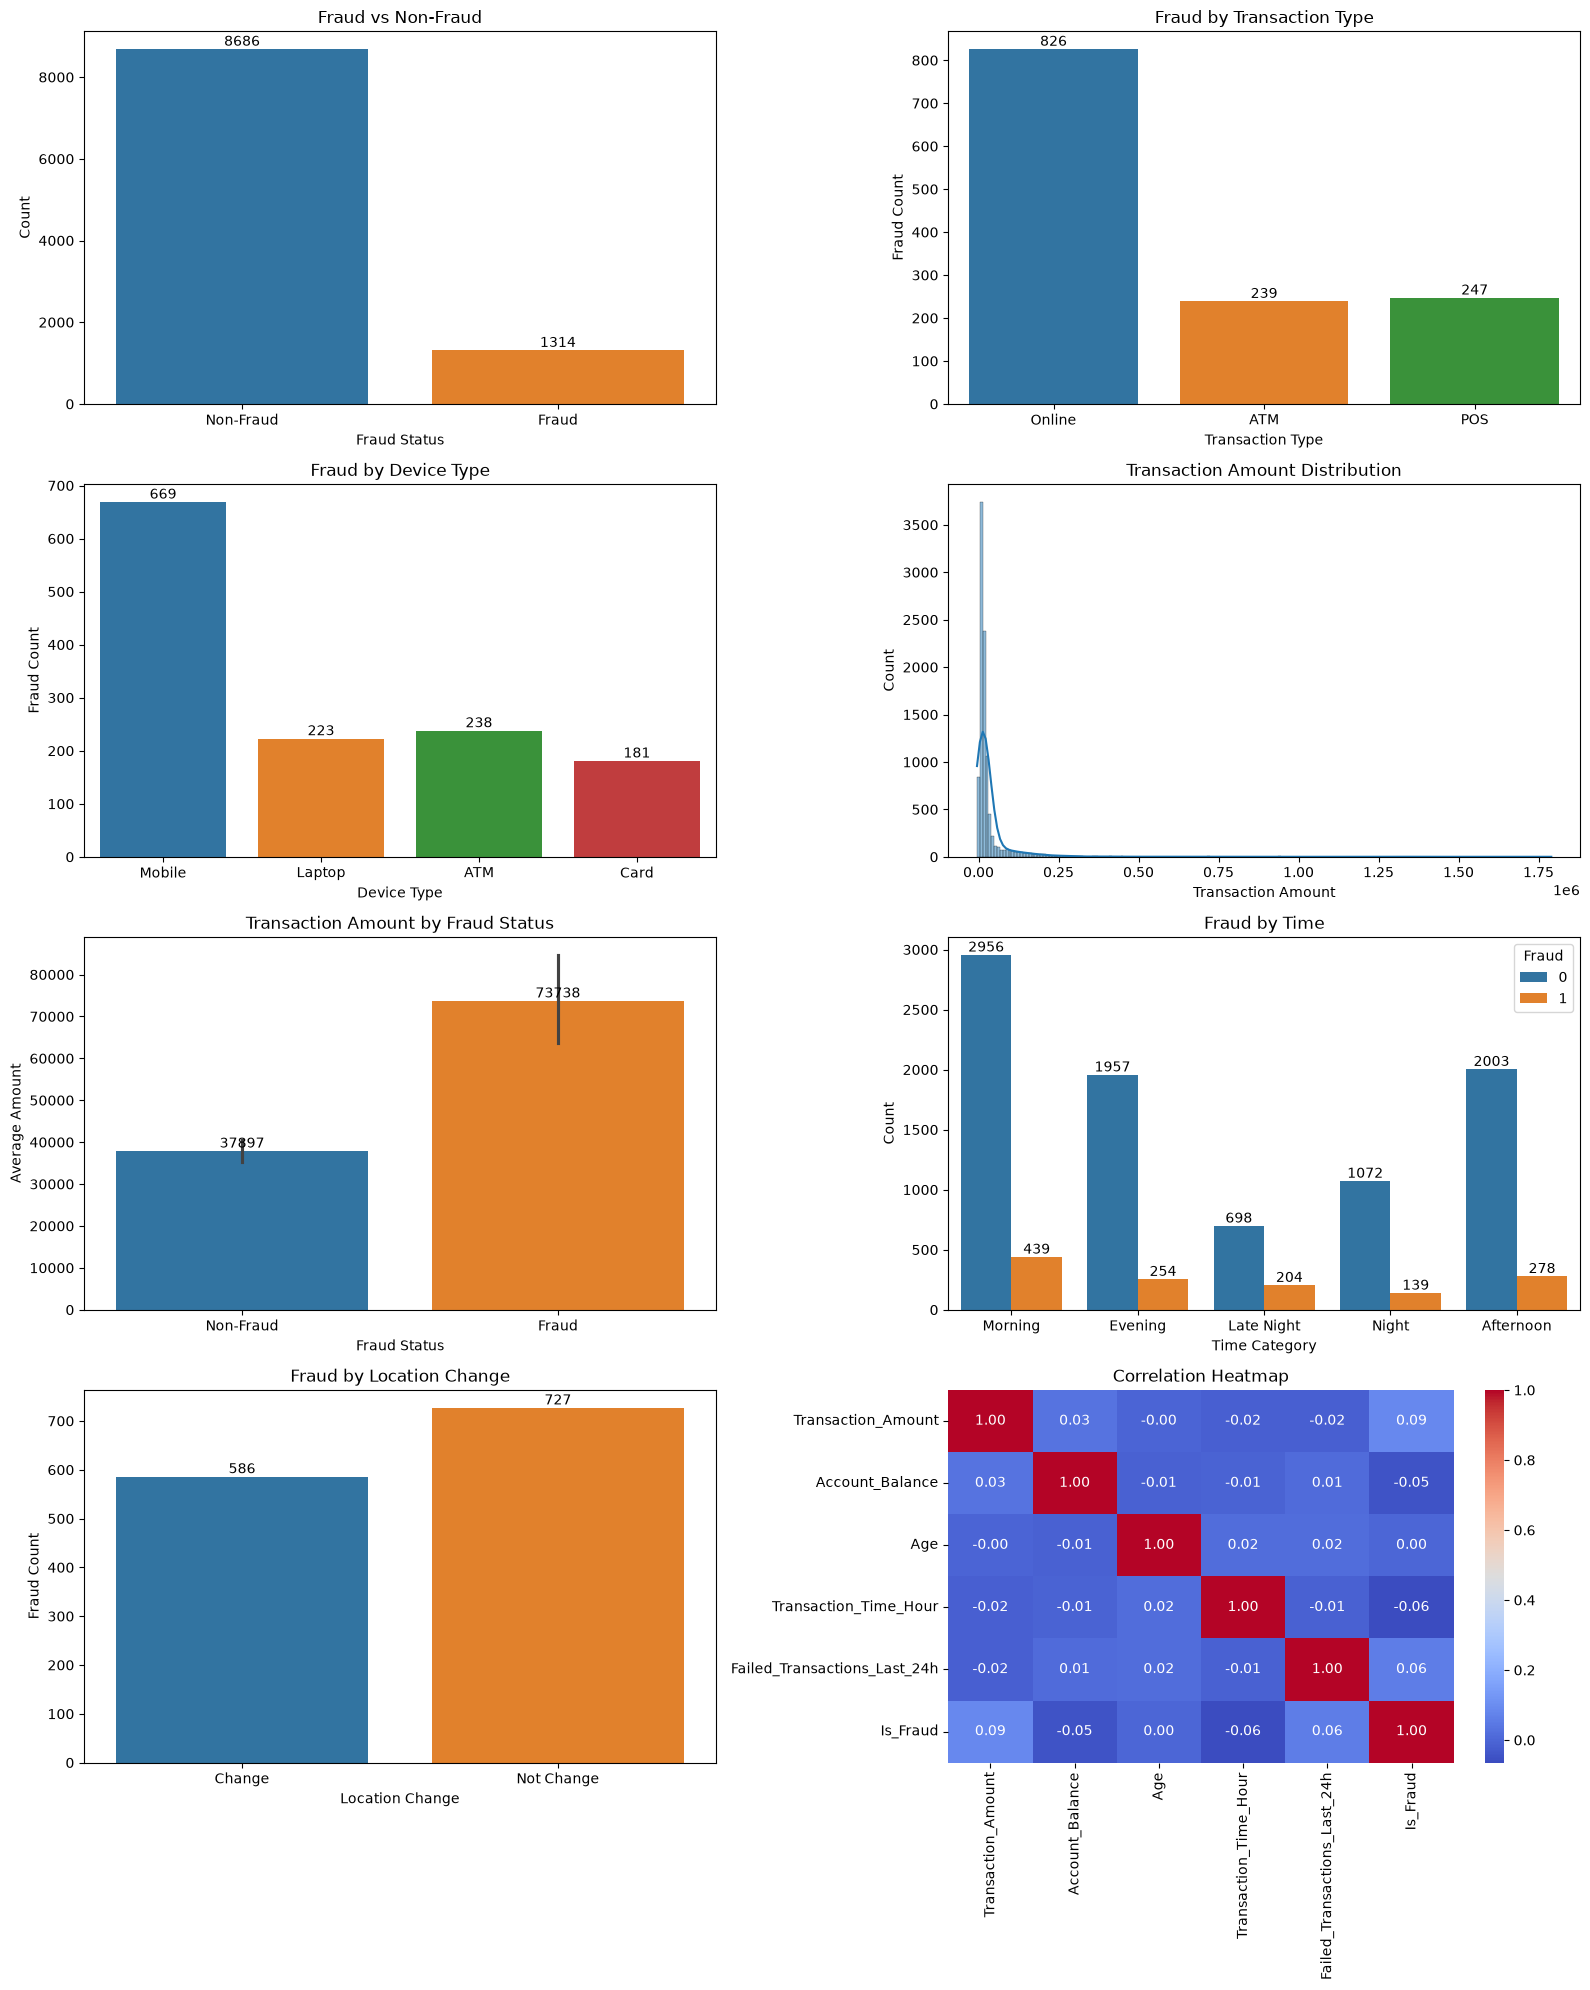

In [ ]:
plt.figure(figsize=(16, 20))


# 1. Fraud vs Non-Fraud
plt.subplot(4, 2, 1)

ax = sns.countplot(
    x='Is_Fraud',
    hue='Is_Fraud',
    data=df,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.xlabel('Fraud Status')
plt.ylabel('Count')
plt.title('Fraud vs Non-Fraud')


# 2. Fraud by Transaction Type
plt.subplot(4, 2, 2)

types = ['Online', 'ATM', 'POS']
values = [onlinefraud, ATM_fraud, POS_fraud]

ax = sns.barplot(
    x=types,
    y=values,
    hue=types,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Transaction Type')
plt.ylabel('Fraud Count')
plt.title('Fraud by Transaction Type')


# 3. Fraud by Device Type
plt.subplot(4, 2, 3)

types = ['Mobile', 'Laptop', 'ATM', 'Card']
values = [Mobile_fraud, Laptop_fraud, ATM_Fraud, Card_Fraud]

ax = sns.barplot(
    x=types,
    y=values,
    hue=types,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Device Type')
plt.ylabel('Fraud Count')
plt.title('Fraud by Device Type')


# 4. Transaction Amount Distribution
plt.subplot(4, 2, 4)

sns.histplot(
    data=df,
    x='Transaction_Amount',
    kde=True
)

plt.xlabel('Transaction Amount')
plt.ylabel('Count')
plt.title('Transaction Amount Distribution')


# 5. Transaction Amount by Fraud Status
plt.subplot(4, 2, 5)

ax = sns.barplot(
    x='Is_Fraud',
    y='Transaction_Amount',
    hue='Is_Fraud',
    data=df,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.xlabel('Fraud Status')
plt.ylabel('Average Amount')
plt.title('Transaction Amount by Fraud Status')


# 6. Fraud by Time
plt.subplot(4, 2, 6)

ax = sns.countplot(
    x='Time_Category',
    hue='Is_Fraud',
    data=df
)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Time Category')
plt.ylabel('Count')
plt.title('Fraud by Time')
plt.legend(title='Fraud')


# 7. Fraud by Location Change
plt.subplot(4, 2, 7)

data = pd.DataFrame({
    'Location': ['Change', 'Not Change'],
    'Count': [locationchange, locationnotchange]
})

ax = sns.barplot(
    x='Location',
    y='Count',
    hue='Location',
    data=data,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Location Change')
plt.ylabel('Fraud Count')
plt.title('Fraud by Location Change')


# 8. Correlation Heatmap
plt.subplot(4, 2, 8)

corr = df[
    ['Transaction_Amount',
     'Account_Balance',
     'Age',
     'Transaction_Time_Hour',
     'Failed_Transactions_Last_24h',
     'Is_Fraud']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')


plt.tight_layout()
plt.show()

Phase 14 – Feature Engineering

In [ ]:
#Feature 1 – Transaction Ratio
df['Transaction_Ratio']=df['Transaction_Amount']/df['Account_Balance']

In [ ]:
#Feature 2 – High Value Transaction
df['Is_High_Value']=df['Transaction_Amount'].apply(lambda x:'Yes' if x>100000 else 
                                                   'No')

In [ ]:
#Feature 3 – High Risk Time
df['High_Risk_Time']=df['Transaction_Time_Hour'].apply(lambda x:'Yes' if 0<=x<=4 else 
                                                   'No')

In [ ]:
#Feature 4 – High Failed Attempts
df['High_Failed_Attempts']=df['Failed_Transactions_Last_24h'].apply(lambda x:'Yes' if x>=3 else 
                                                   'No')

In [ ]:
df.drop('High Risk Time',axis=1,inplace=True)

In [ ]:
df.columns #checking newly added columns


Index(['Transaction_ID', 'Customer_ID', 'Age', 'City', 'Transaction_Amount',
       'Transaction_Type', 'Account_Balance', 'Device_Type', 'Location_Change',
       'Transaction_Time_Hour', 'Is_Weekend', 'Failed_Transactions_Last_24h',
       'Is_Fraud', 'Time_Category', 'Transaction_Ratio', 'Is_High_Value',
       'High_Failed_Attempts', 'High_Risk_Time'],
      dtype='str')

Phase 15 – Identify Suspicious Transactions

In [ ]:
df['Potentially_Suspicious'] = (
    (df['Is_High_Value'] == 'Yes') |
    (df['Location_Change'] == 'Yes') |
    (df['High_Risk_Time'] == 'Yes') |
    (df['High_Failed_Attempts'] == 'Yes') |
    (df['Transaction_Ratio'] > 1)
)

In [ ]:
df['Potentially_Suspicious'] = df['Potentially_Suspicious'].map({
    True: 'Yes',
    False: 'No'
})

In [ ]:
df.head() #checking

,Transaction_ID,Customer_ID,Age,City,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location_Change,Transaction_Time_Hour,Is_Weekend,Failed_Transactions_Last_24h,Is_Fraud,Time_Category,Transaction_Ratio,Is_High_Value,High_Failed_Attempts,High_Risk_Time,Potentially_Suspicious
0,TXN000001,CUST00224,51.0,Mumbai,20165.96,ATM,11695.06,ATM,No,10.0,Yes,0.0,0,Morning,1.724314,No,No,No,Yes
1,TXN000002,CUST01935,27.0,Bengaluru,80057.08,Online,67506.61,Mobile,Yes,17.0,No,0.0,0,Evening,1.185915,No,No,No,Yes
2,TXN000003,CUST01637,37.0,Bengaluru,11593.67,POS,44740.16,Mobile,Yes,4.0,Yes,1.0,1,Late Night,0.259133,No,No,Yes,Yes
3,TXN000004,CUST01098,54.0,Chennai,11208.39,POS,261985.75,Mobile,No,20.0,No,0.0,0,Evening,0.042782,No,No,No,No
4,TXN000005,CUST01083,54.0,Bengaluru,12673.87,Online,21390.58,Mobile,No,11.0,No,0.0,0,Morning,0.592498,No,No,No,No


Final Business Analysis

1. What are the strongest indicators of fraudulent transactions?
The strongest indicators are Location Change and multiple Failed Transactions (especially 3+). Online transactions and Mobile devices also show higher fraud rates.

2. Are high-value transactions more likely to be fraudulent?
There is a weak positive relationship between transaction amount and fraud. High-value transactions should be monitored, but they should not automatically be considered fraudulent.

3. Does a location change indicate higher fraud risk?
Yes. Fraud rate is 27.23% when the location changes, compared with 9.28% when it does not.

4. Does transaction time influence fraud?
Transaction time has a weak relationship with fraud. It can be used as a supporting indicator, but not as a strong standalone indicator.

5. Does the number of failed transactions correlate with fraud?
Yes. Fraud rates become noticeably higher with 3 or more failed transactions, reaching around 28–30%.

6. Which transaction type has the highest fraud rate?
Online transactions — 16.01%.

7. Which device type has the highest fraud rate?
Mobile devices — 16.91%.

8. Are outliers necessarily fraudulent?
No. An outlier is simply an unusual value. It can be a legitimate transaction or a fraudulent one.

9. Which variables should the bank monitor more closely?
The bank should closely monitor Location Change, Failed Transactions, Transaction Type, Device Type, Transaction Amount, Transaction Time, and Transaction-to-Account-Balance Ratio.

10. What recommendations would you give to the bank?
Use a multi-factor fraud detection system instead of relying on one variable. Give higher risk scores to transactions with location changes, multiple failed attempts, unusual amounts, or suspicious timing, and use additional verification before blocking legitimate transactions.

Final Business Conclusion

Key Insights:
Fraud is influenced by a combination of transaction, location, device, and behavioral patterns.
Location changes and repeated failed transactions are the most noticeable risk signals.
No single variable should be treated as definite proof of fraud.

Key Findings:
Finding 1: Location changes have a higher fraud rate (27.23%) compared to no location change (9.28%).

Finding 2: Transactions with 3 or more failed attempts show noticeably higher fraud rates.

Finding 3: Online transactions have the highest fraud rate (16.01%).

Finding 4: Mobile transactions have the highest fraud rate (16.91%).

Finding 5: Transaction amount and time have weak relationships with fraud and should be used as supporting indicators.

Business Recommendations:

Recommendation 1: 
Closely monitor transactions with location changes and multiple failed attempts.

Recommendation 2: 
Give additional scrutiny to online and mobile transactions when combined with other risk signals.

Recommendation 3: 
Use a multi-factor risk scoring system rather than relying on a single indicator to identify potentially fraudulent transactions.